# 02 -- Funnel Analysis
**B2B Full-Funnel Attribution** | Meta DS V Portfolio

Deep-dive into full-funnel conversion metrics, stage durations, and velocity trends.

Key questions:
- What are the overall lead to Closed Won conversion rates?
- Where does the funnel lose the most volume?
- Which stages are taking longer than benchmarks?
- How is funnel velocity trending month over month?


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = r"C:/Users/syeda/b2b-full-funnel-attribution"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import sqlite3
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Image, display
import config

sns.set_theme(style="whitegrid", palette="muted")
os.makedirs("visuals", exist_ok=True)
conn = sqlite3.connect(config.DB_PATH)
print("Connected | working dir:", os.getcwd())


Connected | working dir: C:\Users\syeda\b2b-full-funnel-attribution


## 1. Full-Funnel Conversion Waterfall

In [2]:
from src.funnel_engine import run_funnel_waterfall, run_stage_durations, run_monthly_velocity

waterfall = run_funnel_waterfall(conn)
print("=== Funnel Waterfall ===")
print(waterfall.to_string(index=False))


=== Funnel Waterfall ===
 total_leads  total_mql  total_sql  total_sal  total_opp  total_won  lead_to_mql  mql_to_sql  sql_to_sal  sal_to_opp  opp_to_won  cumulative_top_to_won
       87102      34693      13805      10597       9145       2788       0.3983      0.3979      0.7676       0.863      0.3049                  0.032


### Plotly Funnel Chart

In [3]:
stages = ["Leads", "MQL", "SQL", "SAL", "Opportunity", "Closed Won"]
values = [
    int(waterfall["total_leads"].iloc[0]),
    int(waterfall["total_mql"].iloc[0]),
    int(waterfall["total_sql"].iloc[0]),
    int(waterfall["total_sal"].iloc[0]),
    int(waterfall["total_opp"].iloc[0]),
    int(waterfall["total_won"].iloc[0]),
]

fig = go.Figure(go.Funnel(
    y=stages, x=values,
    textinfo="value+percent initial",
    marker={"color": ["#1f77b4","#aec7e8","#ffbb78","#98df8a","#d62728","#2ca02c"]},
))
fig.update_layout(
    title="B2B Full-Funnel Conversion Waterfall",
    font={"size": 13}, height=420,
)
fig.write_html("visuals/02_funnel_waterfall.html")
print("Saved visuals/02_funnel_waterfall.html")


Saved visuals/02_funnel_waterfall.html


## 2. Monthly Velocity Trends

=== Monthly Velocity (last 6 months) ===
  month  new_leads  mqls  sqls  opps  closed_won  mql_mom_pct  opp_mom_pct
2025-04       4079  1584   613   419         130          6.4          5.8
2025-05       4168  1669   686   460         149          5.4          9.8
2025-06       4205  1636   676   443         139         -2.0         -3.7
2025-07       4260  1614   657   439         130         -1.3         -0.9
2025-08       4300  1665   647   422         111          3.2         -3.9
2025-09       4122  1613   640   406          66         -3.1         -3.8


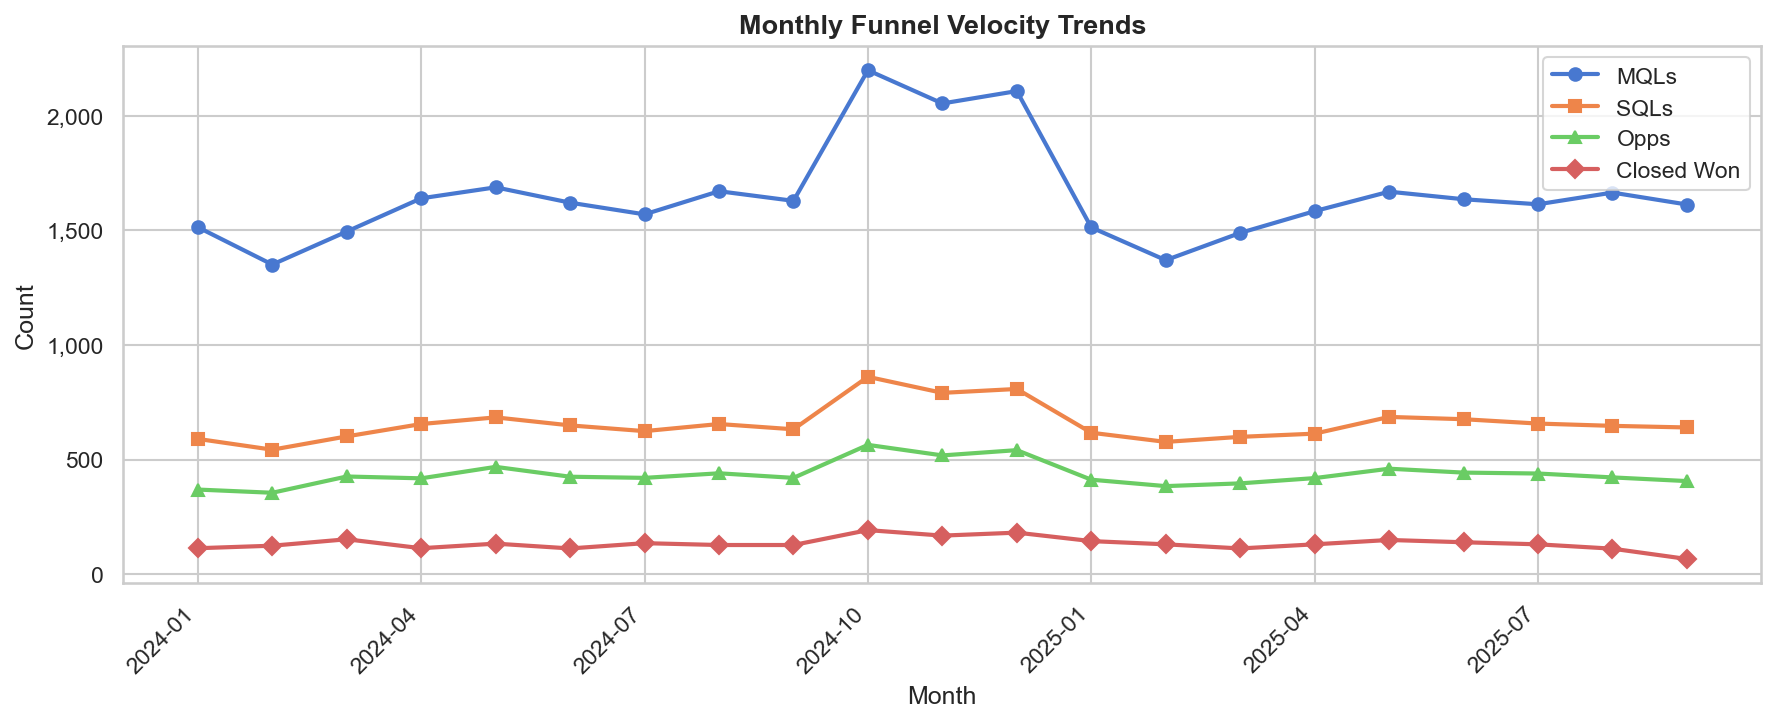

In [4]:
velocity = run_monthly_velocity(conn)
print("=== Monthly Velocity (last 6 months) ===")
print(velocity.tail(6)[["month","new_leads","mqls","sqls","opps",
                          "closed_won","mql_mom_pct","opp_mom_pct"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(velocity["month"], velocity["mqls"],   marker="o", label="MQLs",       linewidth=2)
ax.plot(velocity["month"], velocity["sqls"],   marker="s", label="SQLs",       linewidth=2)
ax.plot(velocity["month"], velocity["opps"],   marker="^", label="Opps",       linewidth=2)
ax.plot(velocity["month"], velocity["closed_won"], marker="D", label="Closed Won", linewidth=2)
ax.set_xlabel("Month")
ax.set_ylabel("Count")
ax.set_title("Monthly Funnel Velocity Trends", fontsize=13, fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(range(0, len(velocity), 3), velocity["month"].iloc[::3], rotation=45, ha="right")
plt.tight_layout()
plt.savefig("visuals/02_monthly_velocity.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/02_monthly_velocity.png"))


## 3. Stage Duration Box Plots

=== Stage Durations (avg / median / P75 / P90) ===
stage_name     n  avg_days  median_approx  p75_days  p90_days
       MQL 13805      18.1            1.0      18.0      28.0
       SQL 10597       6.9            1.0       7.0      11.0
       SAL  9145      11.8            1.0      11.0      18.0


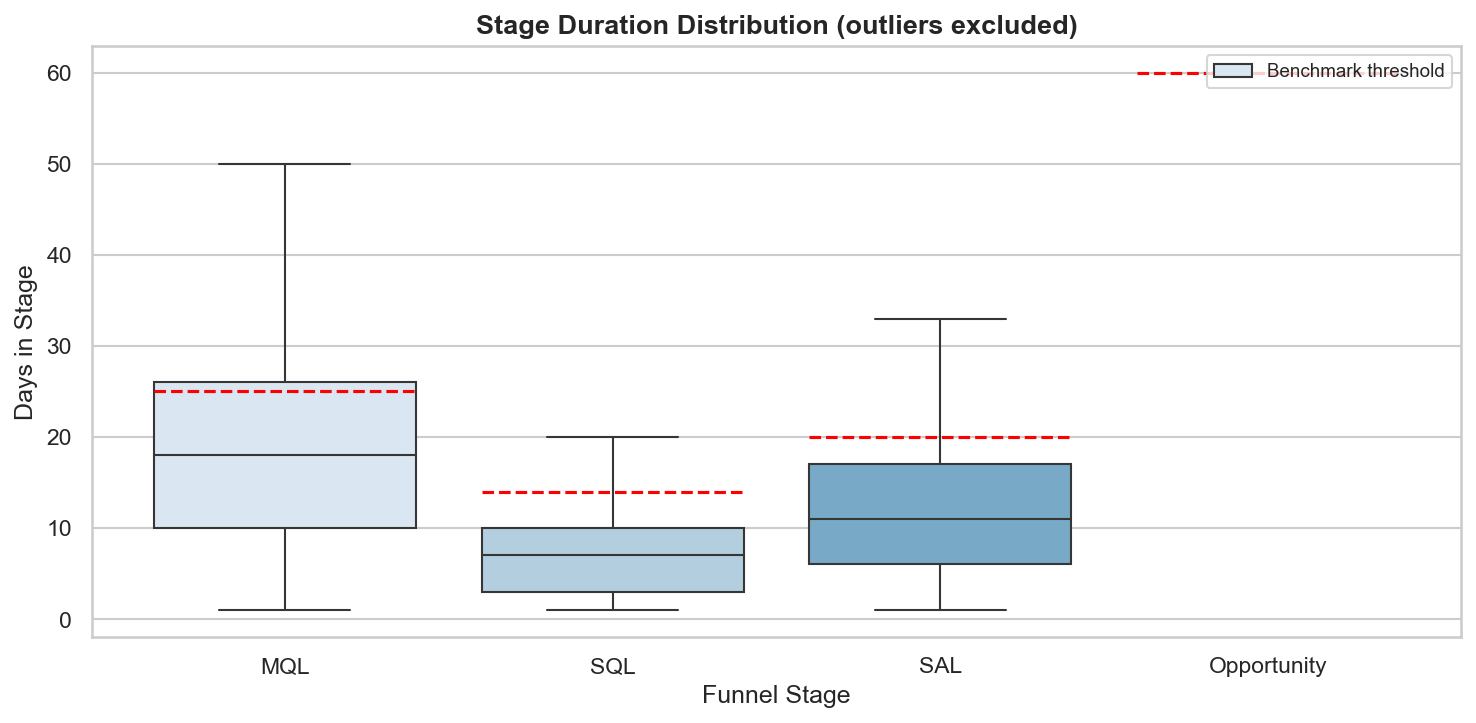

In [5]:
durations = run_stage_durations(conn)
print("=== Stage Durations (avg / median / P75 / P90) ===")
print(durations.to_string(index=False))

raw_dur_sql = (
    "SELECT stage_name, days_in_stage FROM lead_stages"
    " WHERE days_in_stage >= 0 AND days_in_stage <= 120"
    " AND stage_name IN ('MQL','SQL','SAL','Opportunity','Negotiation')"
)
raw_dur = pd.read_sql_query(raw_dur_sql, conn)

STAGE_ORDER = ["MQL", "SQL", "SAL", "Opportunity", "Negotiation"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=raw_dur, x="stage_name", y="days_in_stage",
    order=STAGE_ORDER, palette="Blues", ax=ax, showfliers=False,
)
ax.set_xlabel("Funnel Stage")
ax.set_ylabel("Days in Stage")
ax.set_title("Stage Duration Distribution (outliers excluded)", fontsize=13, fontweight="bold")
benchmarks = {"MQL": 25, "SQL": 14, "SAL": 20, "Opportunity": 60}
for i, stage in enumerate(STAGE_ORDER):
    if stage in benchmarks:
        ax.hlines(benchmarks[stage], i-0.4, i+0.4, colors="red",
                  linestyles="--", linewidth=1.5)
ax.legend(["Benchmark threshold"], loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("visuals/02_stage_durations.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/02_stage_durations.png"))


## 4. Bottleneck Identification & Recommendations

In [6]:
BOTTLENECK_DAYS = {"MQL": 25, "SQL": 14, "SAL": 20, "Opportunity": 60}
print("=== Bottleneck Analysis ===\n")
bottlenecks_found = []
for _, row in durations.iterrows():
    stage = row["stage_name"]
    avg   = row["avg_days"]
    threshold = BOTTLENECK_DAYS.get(stage, 999)
    flag = "BOTTLENECK" if avg > threshold else "OK"
    if flag == "BOTTLENECK":
        bottlenecks_found.append((stage, avg, threshold))
    print(f"  {stage:15s}  avg={avg:.1f}d  threshold={threshold}d  [{flag}]")

print("\n=== Recommendations ===")
if bottlenecks_found:
    for stage, avg, thresh in bottlenecks_found:
        over = avg - thresh
        print(f"  * {stage}: {avg:.1f} days avg (benchmark {thresh}d). "
              f"Consider SDR SLA enforcement to reduce by ~{over:.0f} days.")
else:
    print("  All stages within benchmark thresholds.")


=== Bottleneck Analysis ===

  MQL              avg=18.1d  threshold=25d  [OK]
  SQL              avg=6.9d  threshold=14d  [OK]
  SAL              avg=11.8d  threshold=20d  [OK]

=== Recommendations ===
  All stages within benchmark thresholds.


In [7]:
conn.close()
print("Done.")


Done.
